Por: Juan Aros y Alma Wettig

# Modelo 02: k-Nearest Neighbours + Gradient Boosting
El clasificador k-Nearest Neighbors (k-NN) y el clasificador Gradient Boosting. El k-NN es un método sencillo y efectivo que clasifica cada punto basándose en la mayoría de sus vecinos más cercanos, ideal para capturar relaciones locales en el espacio de características. Por otro lado, Gradient Boosting es una técnica avanzada de ensamble que construye modelos secuenciales para corregir errores de modelos anteriores, ofreciendo gran precisión y robustez en tareas de clasificación complejas. Ambos modelos se entrenan y evalúan con los datos de cobertura del suelo extraídos de la imagen Sentinel-2, y sus resultados se visualizan a través de mapas de clasificación para facilitar la comparación y el análisis espacial.

# 1. Preparación
Importación de librerías para procesamiento y análisis de datos geoespaciales:
 - rasterio y shapely para manejar imágenes raster y geometrías vectoriales.
 - geopandas para cargar y manipular shapefiles.

 Importación de herramientas de aprendizaje automático de scikit-learn:
 - clasificadores k-NN y Gradient Boosting.
 - división de datos en entrenamiento y prueba.
 - evaluación del modelo con métricas estándar.

 Utilidades para visualización con matplotlib y almacenamiento de modelos entrenados con joblib.

In [1]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import mapping
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
import matplotlib.pyplot as plt

# 2. Definición de rutas y carga de datos vectoriales

 Se definen las rutas de los archivos necesarios para el proceso de clasificación:
 - input_img: imagen raster de entrada (Sentinel-2) con resolución espacial de 20 metros.
 - in_msk_img: máscara de píxeles válidos de la imagen (en este caso, todos los valores son válidos).
 - vec_train_file: shapefile con las muestras de entrenamiento etiquetadas, que contiene información sobre las clases de cobertura del suelo.
   
 A continuación, se carga el shapefile usando GeoPandas, lo cual permite acceder a las geometrías y atributos asociados a las muestras de entrenamiento.

In [2]:
# Rutas
input_img = "./DATOS_OUR/sentinel2_2018_input_img.tif"
in_msk_img = "./DATOS_OUR/sentinel2_2018_in_msk_img.tif"
vec_train_file = "./DATOS_OUR/Training/Training.shp"

gdf = gpd.read_file(vec_train_file)

# 3. Apertura y lectura de la imagen raster de entrada usando rasterio.
 Se carga toda la imagen en un arreglo numpy 'img' con dimensiones (bandas, filas, columnas).
 Se extrae el perfil de la imagen para conservar metadatos como proyección y transformaciones geoespaciales.

 Se obtienen las dimensiones de la imagen: número de bandas, filas y columnas.
 Finalmente, se reorganizan los datos en una matriz 2D 'X_all' donde cada fila representa un píxel
 y cada columna corresponde a una banda, facilitando su uso para clasificación.

In [3]:
with rasterio.open(input_img) as src:
    img = src.read()
    profile = src.profile

bands, rows, cols = img.shape
X_all = img.reshape(bands, -1).T

 Se abre la imagen de máscara (in_msk_img) que define los píxeles válidos para clasificación.
 Se lee la primera banda y se aplana para crear un arreglo 1D 'valid_mask' con valores de validez por píxel.

 Inicialización de listas para almacenar características (X_train_list) y etiquetas (y_train_list) de entrenamiento.

 Se recorre cada fila del GeoDataFrame 'gdf', que contiene las geometrías y clases (landcover) de entrenamiento.
 Por cada geometría (polígono de entrenamiento):
   - Se transforma a formato mapeable para rasterio.
   - Se extrae la etiqueta de cobertura terrestre asociada.
   - Se enmascara la imagen de entrada con la geometría usando rasterio.mask (solo se extraen los píxeles dentro del polígono).
   - Se recorren todos los píxeles extraídos, se aplana cada banda y se combinan en vectores.
   - Cada vector de bandas (un píxel) se agrega a X_train_list y su clase correspondiente a y_train_list.

In [4]:
with rasterio.open(in_msk_img) as msk_src:
    valid_mask = msk_src.read(1).flatten()

X_train_list, y_train_list = [], []
for _, row in gdf.iterrows():
    geom = [mapping(row.geometry)]
    label = row["landcover"]

    with rasterio.open(input_img) as src:
        out_image, out_transform = mask(src, geom, crop=True)
        for pixel in zip(*[band.flatten() for band in out_image]):
            X_train_list.append(pixel)
            y_train_list.append(label)

 Se convierten las listas de entrenamiento en arreglos tipo NumPy:
  - X_train contiene los vectores de características (valores espectrales de píxeles).
   - y_train contiene las etiquetas correspondientes (clases de cobertura terrestre).

 Se realiza la división del conjunto de datos en entrenamiento y prueba:
   - El 80% de los datos se usa para entrenamiento (X_train_, y_train_).
   - El 20% restante se reserva para prueba (X_test, y_test).
   - Se fija la semilla random_state=42 para asegurar reproducibilidad.

 Se definen dos modelos de clasificación supervisada:
   - k-NN (k-Nearest Neighbors) con k=5 vecinos.
   - Gradient Boosting con 100 estimadores y tasa de aprendizaje 0.1.

In [5]:
X_train = np.array(X_train_list)
y_train = np.array(y_train_list)

X_train_, X_test, y_train_, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

models = {
    "k-NN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1)
}

# 4. Entrenamiento
 Se realiza un ciclo sobre los modelos definidos (k-NN y Gradient Boosting), entrenándolos con los datos de entrenamiento
 previamente divididos. Luego, se evalúa el rendimiento de cada modelo con los datos de prueba mediante un reporte de clasificación.
 Posteriormente, se clasifica la imagen completa utilizando únicamente los píxeles válidos definidos por la máscara, y se reconstruye
 la imagen clasificada con las dimensiones originales. Finalmente, se visualiza el resultado mediante un mapa de clasificación y se
 guarda el modelo entrenado en un archivo .pkl usando joblib, permitiendo su reutilización futura.


 Entrenando k-NN...
 Clasificación k-NN:
               precision    recall  f1-score   support

           1       0.96      0.90      0.93       882
           2       0.97      0.93      0.95      1007
           5       0.98      0.68      0.80       161
           6       0.80      0.95      0.87      1128
           8       0.97      0.72      0.83       234

    accuracy                           0.90      3412
   macro avg       0.94      0.84      0.88      3412
weighted avg       0.91      0.90      0.90      3412

 Clasificando toda la imagen con k-NN...


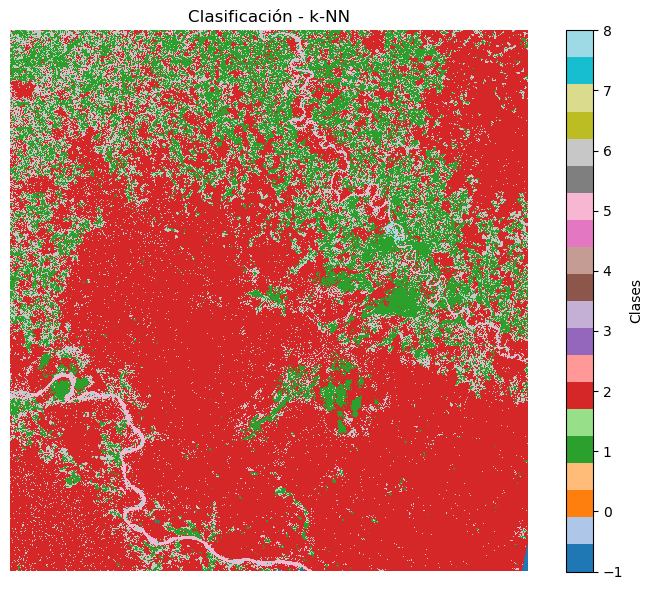


 Entrenando Gradient Boosting...
 Clasificación Gradient Boosting:
               precision    recall  f1-score   support

           1       0.97      0.90      0.93       882
           2       0.98      0.93      0.95      1007
           5       0.98      0.68      0.81       161
           6       0.80      0.96      0.88      1128
           8       0.97      0.72      0.83       234

    accuracy                           0.91      3412
   macro avg       0.94      0.84      0.88      3412
weighted avg       0.92      0.91      0.91      3412

 Clasificando toda la imagen con Gradient Boosting...


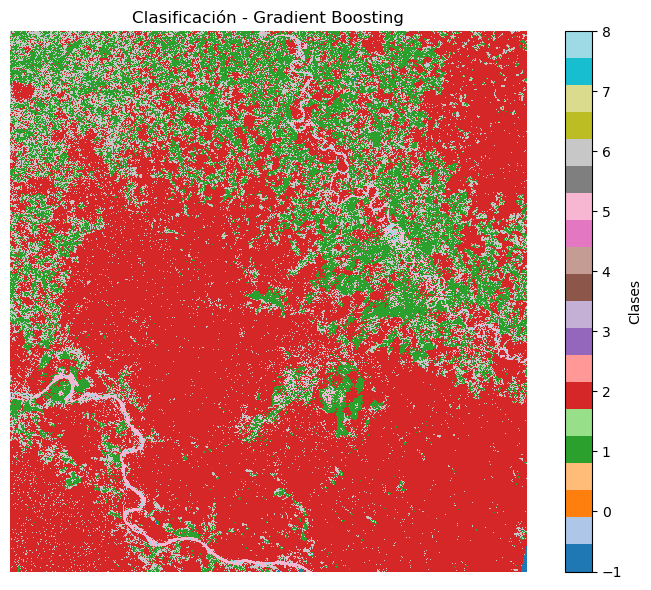

In [6]:
for name, model in models.items():
    print(f"\n Entrenando {name}...")
    model.fit(X_train_, y_train_)
    preds = model.predict(X_test)
    print(f" Clasificación {name}:\n", classification_report(y_test, preds))

    print(f" Clasificando toda la imagen con {name}...")
    prediction = np.full((rows * cols,), fill_value=-1, dtype=np.int32)
    prediction[valid_mask == 1] = model.predict(X_all[valid_mask == 1])
    classification_map = prediction.reshape(rows, cols)

    plt.figure(figsize=(8, 6))
    plt.title(f"Clasificación - {name}")
    plt.imshow(classification_map, cmap="tab20", interpolation='none')
    plt.colorbar(label="Clases")
    plt.axis("off")
    plt.tight_layout()
    plt.show()

    joblib.dump(model, f"modelo_{name.replace(' ', '_').lower()}.pkl")

# 5. Resultados
Los resultados obtenidos tras entrenar y evaluar los modelos k-NN y Gradient Boosting reflejan un buen desempeño general en la clasificación de coberturas terrestres. Ambos modelos alcanzaron una precisión general (accuracy) cercana al 90 %, siendo ligeramente superior en el caso de Gradient Boosting (91 %). Para ambas técnicas, las clases 1 y 2 presentan métricas de precisión y recall superiores al 90 %, lo que indica una alta fiabilidad en su clasificación. Sin embargo, la clase 5 muestra un comportamiento desigual: aunque su precisión es alta (0.98 en ambos modelos), su recall se mantiene bajo (0.68), lo que sugiere que hay varios casos de esta clase que no están siendo correctamente detectados. Por otro lado, la clase 6, aunque con una precisión más baja (0.80), se beneficia de un recall alto (0.95–0.96), lo que significa que el modelo identifica correctamente la mayoría de los casos, aunque con mayor probabilidad de confusión con otras clases. Las métricas promedio ponderadas y macro (f1-score, precision y recall) también confirman una clasificación robusta y equilibrada entre clases. En resumen, ambos modelos ofrecen resultados consistentes y satisfactorios, siendo Gradient Boosting ligeramente superior en rendimiento global.